# MANTA - Non-Rigid Alignment

This notebook aligns two tissue slices non-rigidly using MANTA.

In [1]:
import anndata as ad
import manta
import numpy as np

# I/O
from pathlib import Path

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib inline

## Preprocessing

See `preprocessing.ipynb` for details.

In [4]:
data_dir = Path("/staging/leuven/stg_00002/lcb/lcb_projects/SPF/mkovacic/data/dataset_MOUSE_BRAIN")

In [5]:
source = ad.read_h5ad(data_dir / "slice_75.h5ad")
target = ad.read_h5ad(data_dir / "slice_76.h5ad")

In [6]:
adatas = manta.preprocessing.preprocess(
    source=source,
    target=target,
    gene_key="gene_name",
    spatial_key="X_spatial_coords",
    max_harmony_iterations=25
)

Preprocessing:   0%|          | 0/6 [00:00<?, ?it/s]

In [7]:
source = adatas[0]
target = adatas[1]

## Rigid Alignment

See `rigid_alignment.ipynb` for details.

In [8]:
manta.alignment.rigid(
    source,
    target,
    voxel_scales=[2500, 1000, 500, 250, 125],
    spatial_key="spatial_manta",
    expression_key="X_pca"
)

Rigid Alignment:   0%|          | 0/6 [00:00<?, ?it/s]

## Embedding

See `embedding.ipynb` for details.

In [14]:
manta.sampling.sample(
    adatas=adatas,
    sampler="importance",
    fraction=0.5,
    bin_size=128,
    spatial_key="rigid"
)

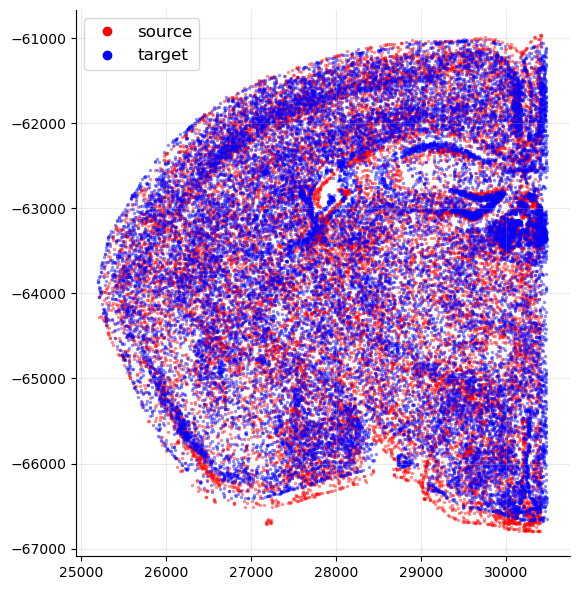

In [15]:
manta.plot.sampling(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],
    sampling_key="sampling",

    figsize=(6, 6),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

In [16]:
manta.embedding.embed(
    adatas=adatas,

    spatial_key="rigid",
    sampling_key="sampling",

    pca_basis_key="X_pca",
    nmf_basis_key="X_nmf",

    # Temporary
    steps_per_epoch = 15,

    # template_k represents the number of latent clusters we would like to represent
    template_k = 64
)

Computing Features:   0%|          | 0/3 [00:00<?, ?it/s]

Training:   0%|          | 0/25 [00:00<?, ?it/s]

## Non-Rigid Alignment

In [17]:
manta.alignment.non_rigid(
    source,
    target,

    embedding_key="embedding",
    clustering_key="embedding_clustering",

    alpha=1.0,
    beta=5.0,
    gamma=0.0,

    rho_src=0.1,
    rho_tgt=0.1,
)

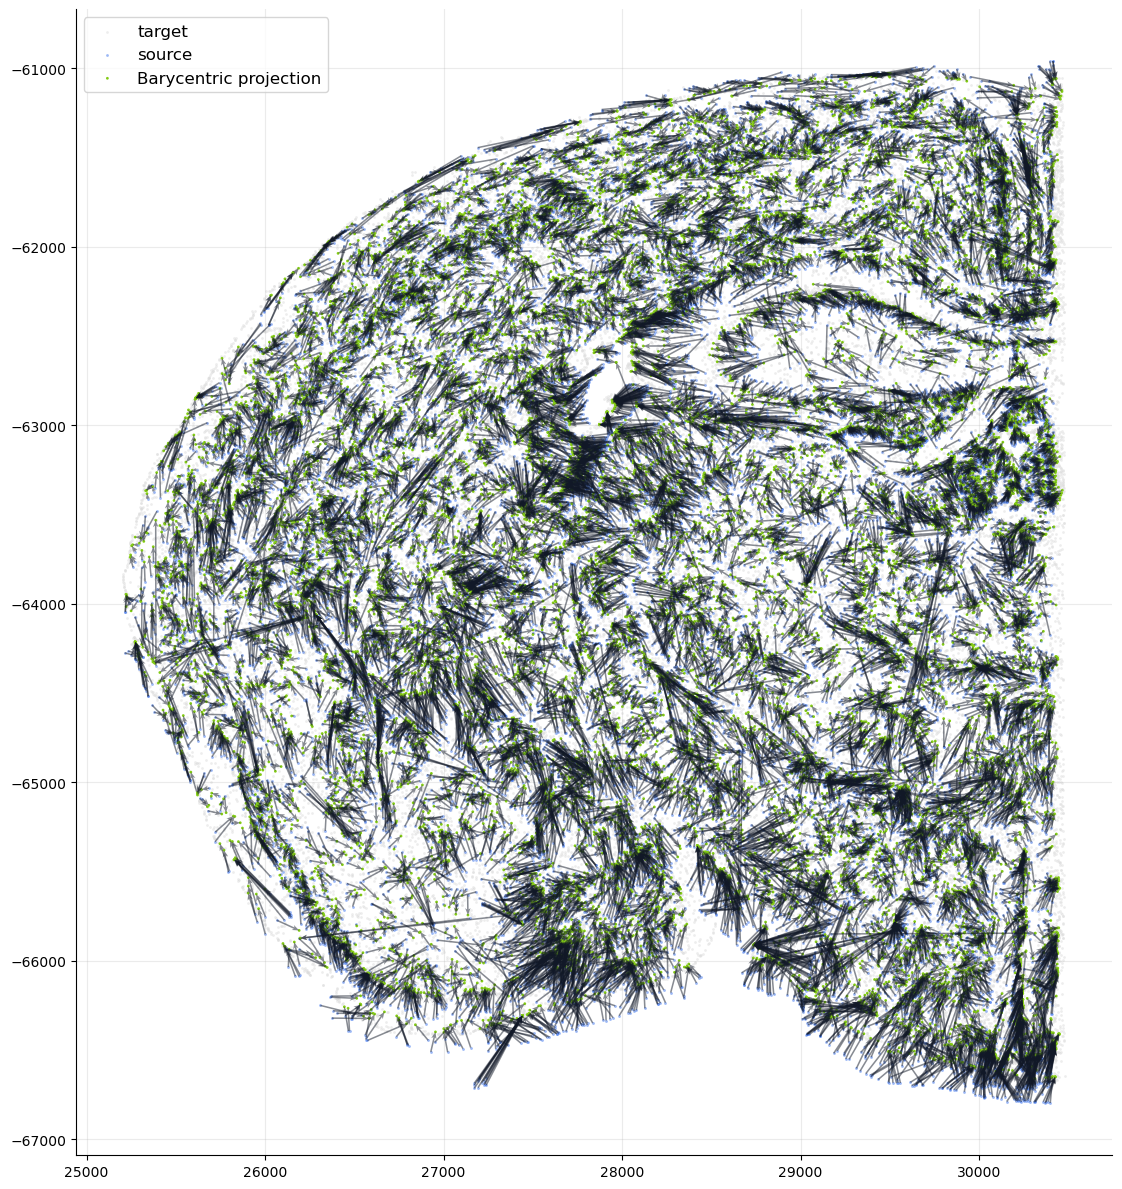

In [18]:
manta.plot.matching(
    source,
    target,

    labels=["source", "target"],

    spatial_key="rigid",

    projection_size=4,
    projection_alpha=1.0,

    arrow_alpha=0.5,
    arrow_width=0.0015,

    max_arrows=None,
    
    figsize=(12,12),
    alpha=0.45,
    marker_size=4,
    equal_aspect=True
)